In [16]:
import pmf_data as pmf

paths = pmf.DataPaths()
matches = pmf.load_json_array(paths.matches_file("England"))

# Match objects use key "wyId" (Wyscout); gameweek is 1-based in this export.
england_gw1_wy_ids = sorted(m["wyId"] for m in matches if m.get("gameweek") == 1)
england_gw1_wy_ids


[2499719,
 2499720,
 2499721,
 2499722,
 2499723,
 2499724,
 2499725,
 2499726,
 2499727,
 2499728]

In [17]:
# Uses `pmf`, `paths`, and `matches` from the cell above.
MATCH_WY_ID = 2499725

teams_by_wy_id = {
    t["wyId"]: t.get("officialName") or t.get("name")
    for t in pmf.load_json(paths.metadata_file("teams.json"))
}

match_row = next(m for m in matches if m["wyId"] == MATCH_WY_ID)
home_tid = away_tid = None
for td in match_row["teamsData"].values():
    if td["side"] == "home":
        home_tid = td["teamId"]
    elif td["side"] == "away":
        away_tid = td["teamId"]

home_team_name = teams_by_wy_id[home_tid]
away_team_name = teams_by_wy_id[away_tid]
{"home": home_team_name, "away": away_team_name, "home_team_id": home_tid, "away_team_id": away_tid}


{'home': 'Newcastle United FC',
 'away': 'Tottenham Hotspur FC',
 'home_team_id': 1613,
 'away_team_id': 1624}

In [18]:
# Uses `pmf`, `paths` from earlier cells; first load parses all England events (large file).
MATCH_WY_ID = 2499725

_england_events = pmf.load_json_array_cached(paths.events_file("England"))
match_events = [e for e in _england_events if e.get("matchId") == MATCH_WY_ID]
# Preview count + first event; full rows are in `match_events`.
len(match_events), match_events[0] if match_events else None


(1750,
 {'eventId': 1,
  'subEventName': 'Ground defending duel',
  'tags': [{'id': 503}, {'id': 701}, {'id': 1802}],
  'playerId': 13484,
  'positions': [{'y': 47, 'x': 62}, {'y': 38, 'x': 55}],
  'matchId': 2499725,
  'eventName': 'Duel',
  'teamId': 1624,
  'matchPeriod': '1H',
  'eventSec': 3.2586859999999973,
  'subEventId': 12,
  'id': 178442225})

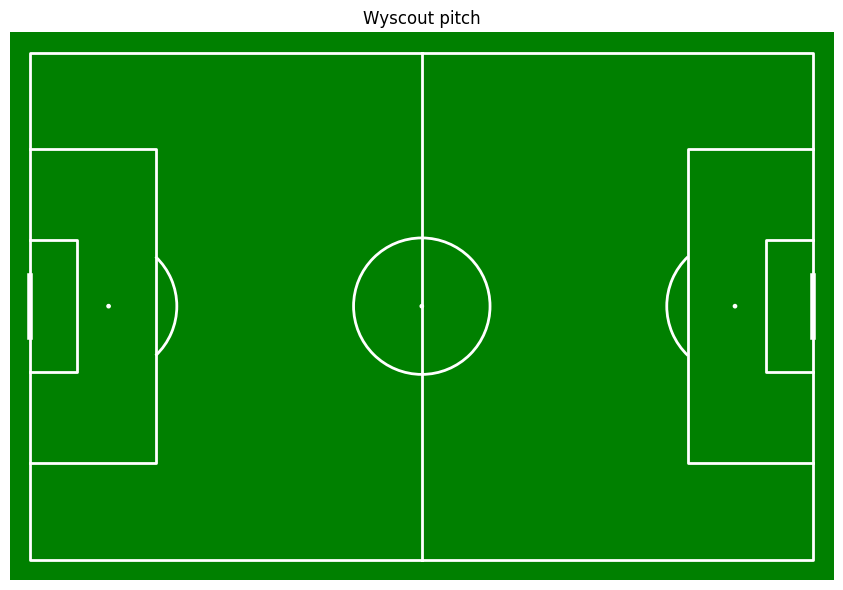

In [19]:
from mplsoccer import Pitch
import matplotlib.pyplot as plt

pitch = Pitch(
    pitch_type="wyscout",
    pitch_color="green",
    line_color="white",
)
fig, ax = pitch.draw(figsize=(9, 6))
ax.set_title("Wyscout pitch")
plt.show()


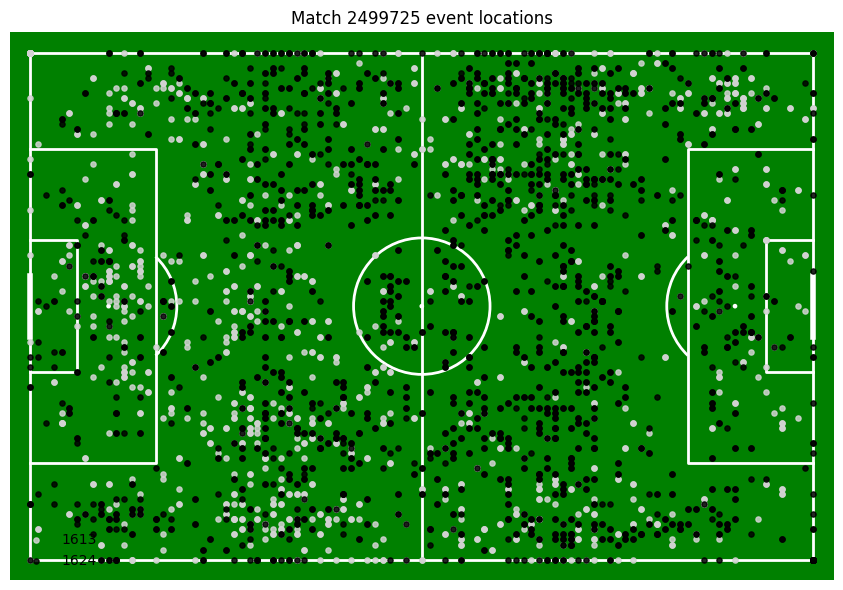

In [20]:
from mplsoccer import Pitch
import matplotlib.pyplot as plt

HOME_TID, AWAY_TID = 1613, 1624

x_home, y_home, x_away, y_away = [], [], [], []
for e in match_events:
    team_id = e.get("teamId")
    for pos in e.get("positions") or []:
        if not isinstance(pos, dict) or "x" not in pos or "y" not in pos:
            continue
        if team_id == HOME_TID:
            x_home.append(float(pos["x"]))
            y_home.append(float(pos["y"]))
        elif team_id == AWAY_TID:
            x_away.append(float(pos["x"]))
            y_away.append(float(pos["y"]))

pitch = Pitch(pitch_type="wyscout", pitch_color="green", line_color="white")
fig, ax = pitch.draw(figsize=(9, 6))

pitch.scatter(x_home, y_home, ax=ax, s=14, color="lightgray", label=str(HOME_TID), alpha=0.85)
pitch.scatter(x_away, y_away, ax=ax, s=14, color="black", label=str(AWAY_TID), alpha=0.85)

ax.set_title("Match 2499725 event locations")
ax.legend(frameon=False)
plt.show()


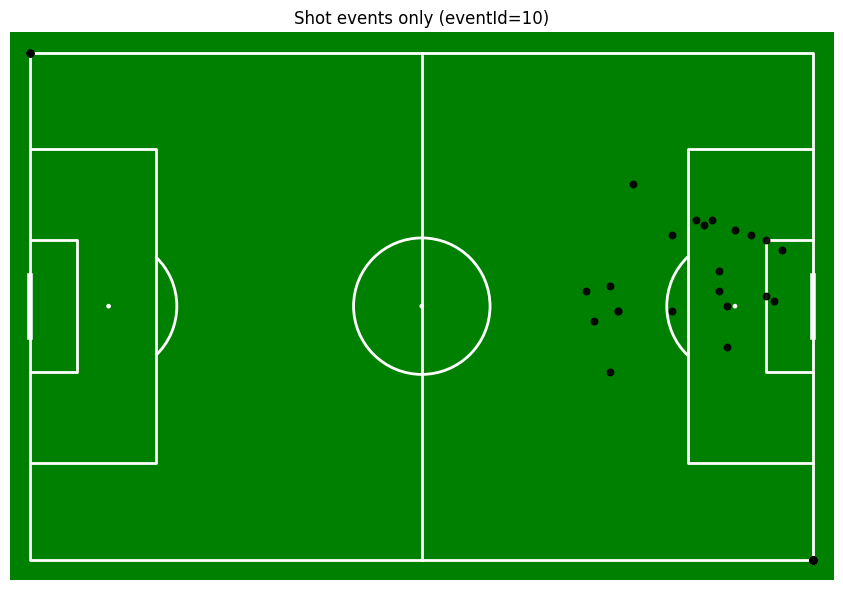

In [21]:
from mplsoccer import Pitch
import matplotlib.pyplot as plt

# Uses `match_events` from earlier cells.
SHOT_EVENT_ID = 10

x_shots, y_shots = [], []
for e in match_events:
    if e.get("eventId") != SHOT_EVENT_ID:
        continue
    for pos in e.get("positions") or []:
        if isinstance(pos, dict) and "x" in pos and "y" in pos:
            x_shots.append(float(pos["x"]))
            y_shots.append(float(pos["y"]))

pitch = Pitch(pitch_type="wyscout", pitch_color="green", line_color="white")
fig, ax = pitch.draw(figsize=(9, 6))
pitch.scatter(x_shots, y_shots, ax=ax, s=22, color="black", alpha=0.9)

ax.set_title(f"Shot events only (eventId={SHOT_EVENT_ID})")
plt.show()


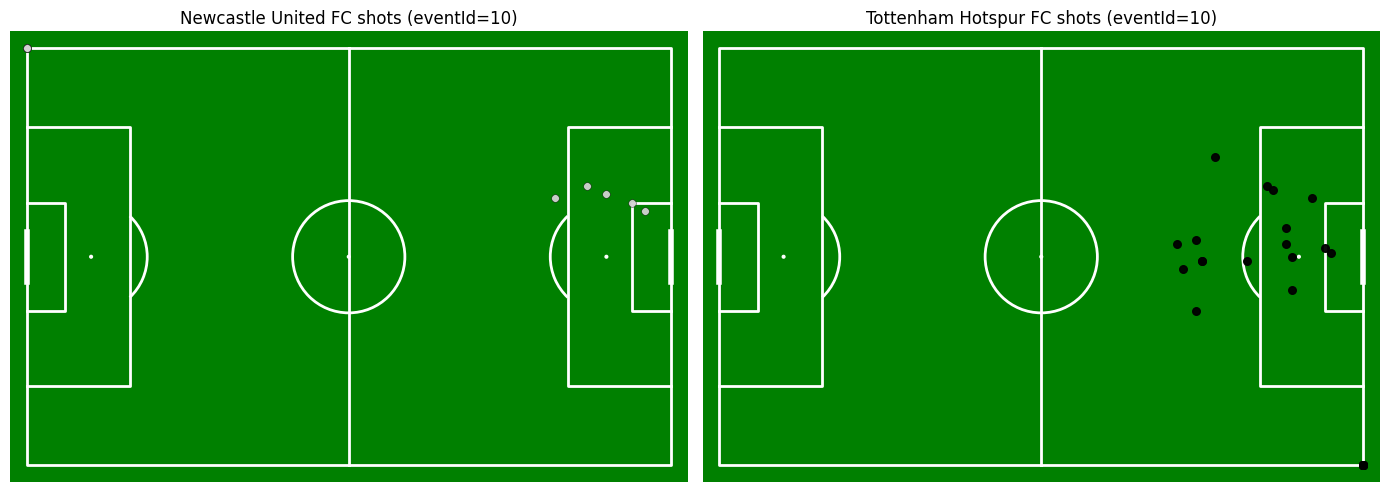

In [22]:
from mplsoccer import Pitch
import matplotlib.pyplot as plt

# Uses `match_events` and (optionally) `home_team_name` / `away_team_name` from earlier cells.
SHOT_EVENT_ID = 10
NEWCASTLE_TID = 1613
TOTTENHAM_TID = 1624

x_new, y_new, x_tot, y_tot = [], [], [], []
for e in match_events:
    if e.get("eventId") != SHOT_EVENT_ID:
        continue
    tid = e.get("teamId")
    for pos in e.get("positions") or []:
        if not isinstance(pos, dict) or "x" not in pos or "y" not in pos:
            continue
        if tid == NEWCASTLE_TID:
            x_new.append(float(pos["x"]))
            y_new.append(float(pos["y"]))
        elif tid == TOTTENHAM_TID:
            x_tot.append(float(pos["x"]))
            y_tot.append(float(pos["y"]))

pitch = Pitch(pitch_type="wyscout", pitch_color="green", line_color="white")
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

pitch.draw(ax=axes[0])
pitch.scatter(x_new, y_new, ax=axes[0], s=30, color="lightgray", edgecolors="black", linewidths=0.3, alpha=0.95)
axes[0].set_title(f"{locals().get('home_team_name', 'Newcastle')} shots (eventId={SHOT_EVENT_ID})")

pitch.draw(ax=axes[1])
pitch.scatter(x_tot, y_tot, ax=axes[1], s=30, color="black", alpha=0.95)
axes[1].set_title(f"{locals().get('away_team_name', 'Tottenham')} shots (eventId={SHOT_EVENT_ID})")

plt.tight_layout()
plt.show()


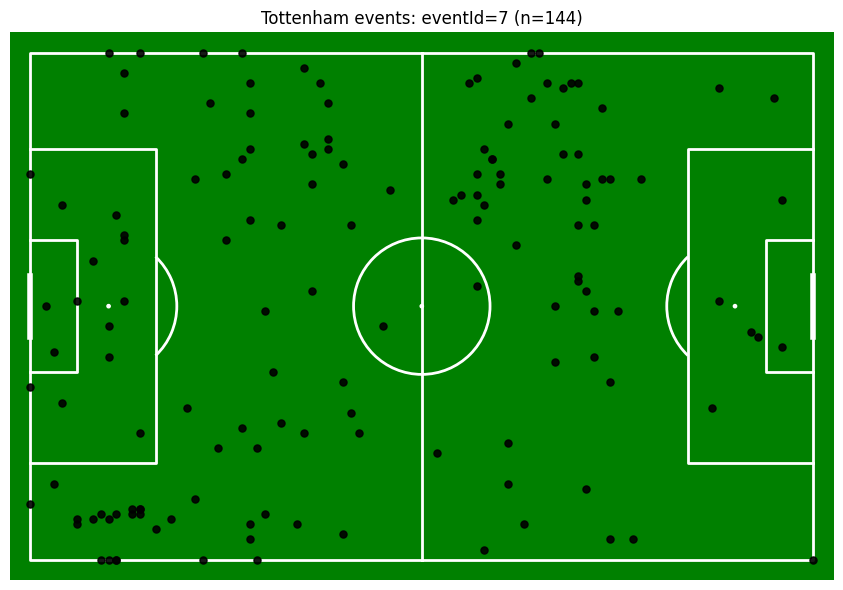

In [23]:
from mplsoccer import Pitch
import matplotlib.pyplot as plt

# Uses `match_events` from earlier cells.
EVENT_ID = 7
TOTTENHAM_TID = 1624

x_evt, y_evt = [], []
for e in match_events:
    if e.get("teamId") != TOTTENHAM_TID:
        continue
    if e.get("eventId") != EVENT_ID:
        continue
    for pos in e.get("positions") or []:
        if isinstance(pos, dict) and "x" in pos and "y" in pos:
            x_evt.append(float(pos["x"]))
            y_evt.append(float(pos["y"]))

pitch = Pitch(pitch_type="wyscout", pitch_color="green", line_color="white")
fig, ax = pitch.draw(figsize=(9, 6))
pitch.scatter(x_evt, y_evt, ax=ax, s=26, color="black", alpha=0.9)
ax.set_title(f"Tottenham events: eventId={EVENT_ID} (n={len(x_evt)})")
plt.show()


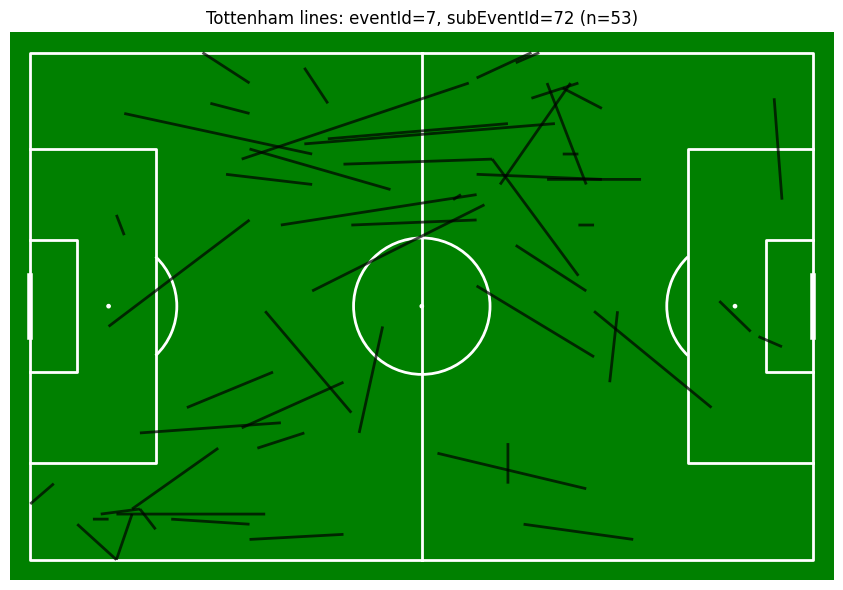

In [25]:
from mplsoccer import Pitch
import matplotlib.pyplot as plt

# Uses `match_events` from earlier cells.
EVENT_ID = 7
SUBEVENT_ID = 72
TOTTENHAM_TID = 1624

xstart, ystart, xend, yend = [], [], [], []

for e in match_events:
    if e.get("teamId") != TOTTENHAM_TID:
        continue
    if e.get("eventId") != EVENT_ID:
        continue
    if e.get("subEventId") != SUBEVENT_ID:
        continue

    pos = e.get("positions")
    if not isinstance(pos, list) or len(pos) < 2:
        continue

    p0, p1 = pos[0], pos[1]
    if not (isinstance(p0, dict) and isinstance(p1, dict)):
        continue
    if not all(k in p0 for k in ("x", "y")) or not all(k in p1 for k in ("x", "y")):
        continue

    xstart.append(float(p0["x"]))
    ystart.append(float(p0["y"]))
    xend.append(float(p1["x"]))
    yend.append(float(p1["y"]))

pitch = Pitch(pitch_type="wyscout", pitch_color="green", line_color="white")
fig, ax = pitch.draw(figsize=(9, 6))

pitch.lines(xstart, ystart, xend, yend, ax=ax, color="black", lw=2, alpha=0.7)

ax.set_title(
    f"Tottenham lines: eventId={EVENT_ID}, subEventId={SUBEVENT_ID} (n={len(xstart)})"
)
plt.show()


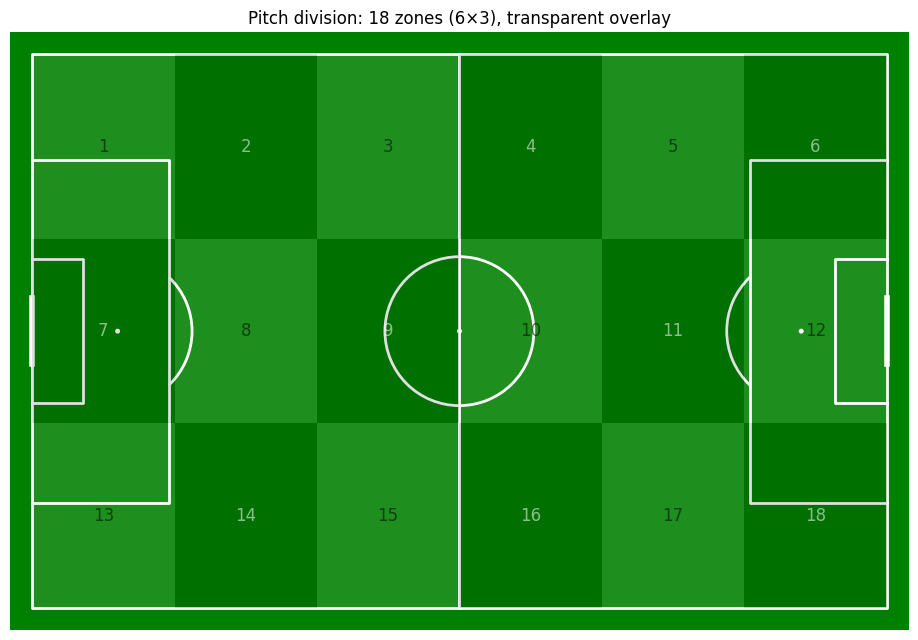

In [27]:
from mplsoccer import Pitch
import matplotlib.pyplot as plt
from matplotlib.patches import Rectangle

# 18 zones as a 6 (x / horizontal) x 3 (y / vertical) grid on Wyscout 0–100 coords.
# Numbering: 1 = bottom-left, then left->right (1..6), then upwards (7..12), ... up to 18.
N_ROWS = 3  # bottom -> top
N_COLS = 6  # left -> right

pitch = Pitch(pitch_type="wyscout", pitch_color="green", line_color="white")
fig, ax = pitch.draw(figsize=(10, 6.5))

zone_w = 100 / N_COLS
zone_h = 100 / N_ROWS

for r in range(N_ROWS):
    for c in range(N_COLS):
        x0 = c * zone_w
        y0 = r * zone_h
        zone_id = r * N_COLS + c + 1

        # chessboard effect
        face = "white" if (r + c) % 2 == 0 else "black"
        ax.add_patch(
            Rectangle(
                (x0, y0),
                zone_w,
                zone_h,
                facecolor=face,
                edgecolor="none",
                alpha=0.12,
                zorder=2,
            )
        )

        # zone numbers (optional but helpful)
        ax.text(
            x0 + zone_w / 2,
            y0 + zone_h / 2,
            str(zone_id),
            ha="center",
            va="center",
            color="white" if face == "black" else "black",
            fontsize=12,
            alpha=0.55,
            zorder=3,
        )

ax.set_title("Pitch division: 18 zones (6×3), transparent overlay")
plt.show()


In [55]:
# Build ball-event sequences from the already loaded `match_events`.
# Rules used:
# - A sequence has a single `teamId` (team of the first included event).
# - End sequence on ANY team change in the raw stream (do not include next).
# - End sequence if next event is Interruption (eventId == 5; do not include next).
# - If the immediate next event is a Shot (eventId == 10) BY THE SAME TEAM, include it and end.
# - Exclude non-ball events from sequence contents: 1, 2, 4, 6, 9.

EXCLUDED_EVENT_IDS = {1, 2, 4, 6, 9}
INTERRUPTION_ID = 5
SHOT_ID = 10


def build_ball_sequences(events):
    sequences = []
    current_seq = []
    seq_team_id = None

    i = 0
    while i < len(events):
        curr = events[i]
        curr_event_id = curr.get("eventId")

        # Keep only ball-relevant events in sequence content.
        if curr_event_id not in EXCLUDED_EVENT_IDS and curr_event_id != INTERRUPTION_ID:
            if seq_team_id is None:
                seq_team_id = curr.get("teamId")
            current_seq.append(curr)

        nxt = events[i + 1] if i + 1 < len(events) else None
        end_seq = False
        skip_next = False

        if nxt is None:
            end_seq = True
        else:
            next_event_id = nxt.get("eventId")
            next_team_id = nxt.get("teamId")

            # Team change anywhere in the stream ends the current possession/sequence.
            if seq_team_id is not None and next_team_id != seq_team_id:
                end_seq = True

            # Interruption starts/marks a break (exclude interruption itself).
            elif next_event_id == INTERRUPTION_ID:
                end_seq = True

            # Include immediate next shot only if it's by the same team, then cut.
            elif next_event_id == SHOT_ID and (seq_team_id is None or next_team_id == seq_team_id):
                if seq_team_id is None:
                    seq_team_id = next_team_id
                current_seq.append(nxt)
                end_seq = True
                skip_next = True

        if end_seq:
            if current_seq:
                sequences.append(current_seq)
            current_seq = []
            seq_team_id = None

        i += 2 if skip_next else 1

    return sequences


ball_sequences = build_ball_sequences(match_events)

len(ball_sequences), [len(seq) for seq in ball_sequences[:10]]


(396, [1, 4, 1, 3, 1, 1, 1, 2, 2, 1])

In [56]:
# Print event names for sequences.
# Uses `ball_sequences` from the previous cell.

# Read subevent labels directly from each event.
def seq_subevent_names(seq):
    return [e.get("subEventName") or f"UNKNOWN_SUB_{e.get('subEventId')}" for e in seq]


def print_sequences(seqs, title):
    print(title)
    print("-" * len(title))
    for i, seq in enumerate(seqs, start=1):
        names = seq_subevent_names(seq)
        print(f"Seq {i} (len={len(seq)}): {names}")
    print()


# 1) First 5 sequences overall
first5_overall = ball_sequences[:5]
print_sequences(first5_overall, "First 5 sequences overall")

# 2) First 5 sequences with length >= 4
seq_len_ge4 = [seq for seq in ball_sequences if len(seq) >= 4][:5]
print_sequences(seq_len_ge4, "First 5 sequences with length >= 4")


First 5 sequences overall
-------------------------
Seq 1 (len=1): ['High pass']
Seq 2 (len=4): ['Throw in', 'Simple pass', 'Simple pass', 'High pass']
Seq 3 (len=1): ['Free Kick']
Seq 4 (len=3): ['Throw in', 'Simple pass', 'Launch']
Seq 5 (len=1): ['Simple pass']

First 5 sequences with length >= 4
----------------------------------
Seq 1 (len=4): ['Throw in', 'Simple pass', 'Simple pass', 'High pass']
Seq 2 (len=6): ['Simple pass', 'Simple pass', 'Simple pass', 'Simple pass', 'Simple pass', 'High pass']
Seq 3 (len=4): ['Simple pass', 'Simple pass', 'Simple pass', 'High pass']
Seq 4 (len=4): ['Simple pass', 'Simple pass', 'Touch', 'Simple pass']
Seq 5 (len=5): ['Simple pass', 'Simple pass', 'Simple pass', 'High pass', 'Simple pass']



In [57]:
# Split sequences by team (based on the first event in each sequence).
# Uses `ball_sequences`, and optionally `teams_by_wy_id` from earlier cells.

sequences_by_team = {}
for seq in ball_sequences:
    if not seq:
        continue
    team_id = seq[0].get("teamId")
    sequences_by_team.setdefault(team_id, []).append(seq)

# Team-specific lists (explicit variables for this match)
newcastle_sequences = sequences_by_team.get(1613, [])
tottenham_sequences = sequences_by_team.get(1624, [])

# Optional readable labels if `teams_by_wy_id` exists.
if "teams_by_wy_id" in globals():
    for tid, seqs in sequences_by_team.items():
        print(f"{teams_by_wy_id.get(tid, tid)} ({tid}): {len(seqs)} sequences")
else:
    for tid, seqs in sequences_by_team.items():
        print(f"team {tid}: {len(seqs)} sequences")

len(newcastle_sequences), len(tottenham_sequences)


Newcastle United FC (1613): 193 sequences
Tottenham Hotspur FC (1624): 203 sequences


(193, 203)

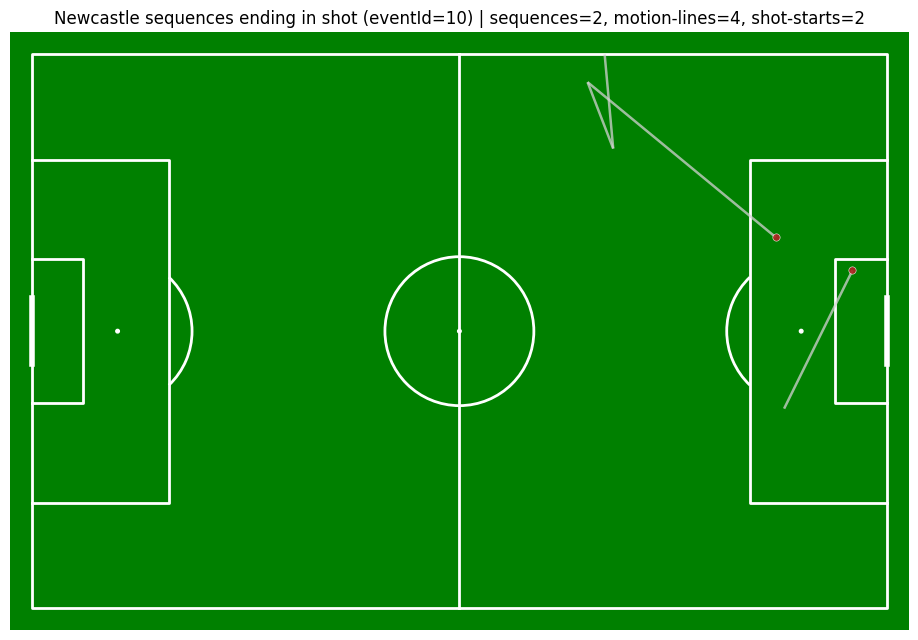

In [58]:
from mplsoccer import Pitch
import matplotlib.pyplot as plt

# Uses `newcastle_sequences` from the previous split cell.
SHOT_ID = 10

newcastle_shot_sequences = [
    seq for seq in newcastle_sequences
    if seq and seq[-1].get("eventId") == SHOT_ID and len(seq) > 1
]

xstart, ystart, xend, yend = [], [], [], []
shot_x, shot_y = [], []
for seq in newcastle_shot_sequences:
    for e in seq:
        pos = e.get("positions")
        if not isinstance(pos, list) or not pos:
            continue
        p0 = pos[0]
        if not (isinstance(p0, dict) and all(k in p0 for k in ("x", "y"))):
            continue

        if e.get("eventId") == SHOT_ID:
            shot_x.append(float(p0["x"]))
            shot_y.append(float(p0["y"]))
            continue

        if len(pos) < 2:
            continue
        p1 = pos[1]
        if not (isinstance(p1, dict) and all(k in p1 for k in ("x", "y"))):
            continue
        xstart.append(float(p0["x"]))
        ystart.append(float(p0["y"]))
        xend.append(float(p1["x"]))
        yend.append(float(p1["y"]))

pitch = Pitch(pitch_type="wyscout", pitch_color="green", line_color="white")
fig, ax = pitch.draw(figsize=(10, 6.5))

if xstart:
    pitch.lines(xstart, ystart, xend, yend, ax=ax, color="lightgray", lw=1.8, alpha=0.75)
if shot_x:
    pitch.scatter(
        shot_x, shot_y, ax=ax, color="firebrick", s=28, zorder=3, alpha=0.9, edgecolors="white", linewidths=0.4,
    )
ax.set_title(
    f"Newcastle sequences ending in shot (eventId={SHOT_ID}) | "
    f"sequences={len(newcastle_shot_sequences)}, motion-lines={len(xstart)}, shot-starts={len(shot_x)}"
)
plt.show()


In [59]:
# Print all shot-ending sequences with IDs, team IDs, subevent labels, and coordinates.
# Uses `newcastle_shot_sequences` from the previous cell.


def event_coord_text(event):
    pos = event.get("positions")
    if not isinstance(pos, list) or not pos:
        return "NO_POS"

    coords = []
    for p in pos:
        if isinstance(p, dict) and "x" in p and "y" in p:
            coords.append(f"({float(p['x']):.1f}, {float(p['y']):.1f})")
    return " -> ".join(coords) if coords else "NO_VALID_COORDS"


print(f"Shot-ending sequences: {len(newcastle_shot_sequences)}")
print("=" * 80)
for seq_idx, seq in enumerate(newcastle_shot_sequences, start=1):
    print(f"Sequence {seq_idx} (len={len(seq)})")
    for ev_idx, ev in enumerate(seq, start=1):
        event_uid = ev.get("id")
        team_id = ev.get("teamId")
        label = ev.get("subEventName") or f"UNKNOWN_SUB_{ev.get('subEventId')}"
        print(
            f"  {ev_idx:02d}. event_id={event_uid} | team_id={team_id} | "
            f"{label}: {event_coord_text(ev)}"
        )
    print("-" * 80)

Shot-ending sequences: 2
Sequence 1 (len=4)
  01. event_id=178442502 | team_id=1613 | Throw in: (67.0, 0.0) -> (68.0, 17.0)
  02. event_id=178442503 | team_id=1613 | Simple pass: (68.0, 17.0) -> (65.0, 5.0)
  03. event_id=178442504 | team_id=1613 | High pass: (65.0, 5.0) -> (87.0, 33.0)
  04. event_id=178442509 | team_id=1613 | Shot: (87.0, 33.0) -> (0.0, 0.0)
--------------------------------------------------------------------------------
Sequence 2 (len=2)
  01. event_id=178443882 | team_id=1613 | Head pass: (88.0, 64.0) -> (96.0, 39.0)
  02. event_id=178443884 | team_id=1613 | Shot: (96.0, 39.0) -> (0.0, 0.0)
--------------------------------------------------------------------------------
